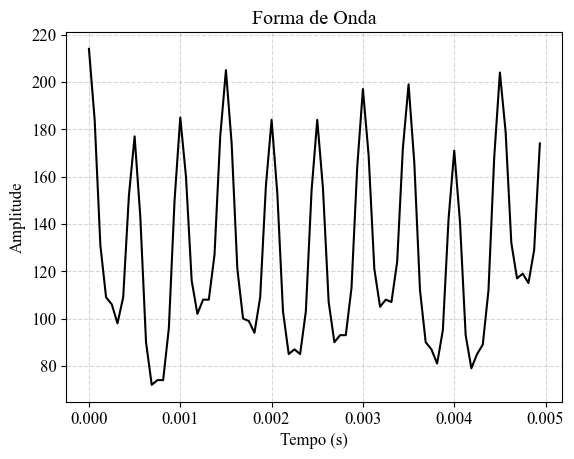

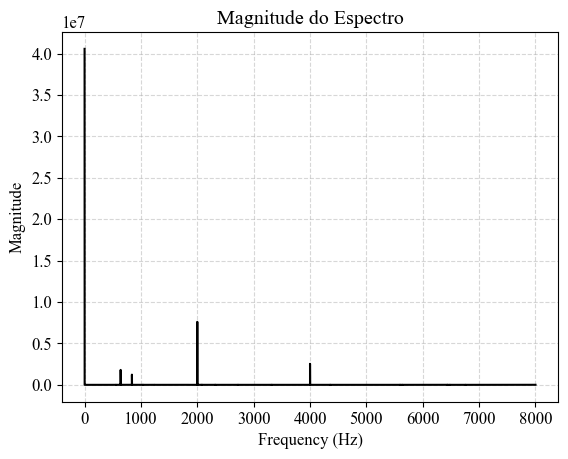

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
import scipy.io.wavfile as wav

plt.rcParams.update({
    "font.family": "serif",            
    "font.serif": ["Times New Roman"], 
    "font.size": 12,                   
    "mathtext.fontset": "cm"           
})

def plot_spectrogram(filename): # Função para ler o wav e plotar o espectro e o sinal
    fs, wav_array = wav.read(filename) # Lê o arquivo e recebe a frequencia de amostragem

    N = len(wav_array) # Armazena o tamanho do array do sinal

    t = np.arange(N) / fs # Cria um array de tempo

    samples = int(0.005 * fs) # Define o número de amostras para os primeiros 5 ms

    plt.plot(t[:samples], wav_array[:samples], color = 'black') # Plota os primeiros 5 ms do sinal
    plt.title("Forma de Onda") # Titulo
    plt.grid(True, linestyle='--', alpha=0.5) # Grid 
    plt.xlabel("Tempo (s)") # Eixo x
    plt.ylabel("Amplitude") # Eixo y
    plt.show()

    mag = np.abs(np.fft.rfft(wav_array, N)) # Armazena na memória a magnitude do espectro
    freq = np.fft.rfftfreq(N, 1/fs) # Armazena o vetor de frequencias

    plt.plot(freq, mag, color = 'black') # Plota o espectro
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.title("Magnitude do Espectro")
    plt.show()

    return fs, wav_array, mag, freq # Retorna a frequencia de amostragem, o array do sinal, a magnitude e o eixo das frequencias

def detectar_frequencias(mag, freq, threshold): # Função para detectar os picos do espectro
    peaks, _ = signal.find_peaks(mag, height = threshold * np.max(mag)) # Função do scipy que retorna os indices dos picos e suas alturas, 
    # onde a altura é definida como um valor mínimo multiplicado pela magnitude máxima do espectro

    print("Número de componentes:", len(peaks)) # Printa o número de componentes

# ============
#  Plotagem
# ============

    plt.plot(freq, mag, color = 'black') 
    plt.scatter(freq[peaks], mag[peaks], color='red')
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Magnitude")
    plt.title("Picos do espectro")
    plt.show()

    print("Frequências detectadas: ", freq[peaks]) # Printa as frequencias detectadas
    return peaks, freq[peaks] # Retorna os indices dos picos e as frequencias correspondentes

def separar_componentes_iir(x, fs, freqs, largura=50, ordem=4): # Função para separar as componentes do sinal 
    # Usando um band-pass IIR Butterworth
    
    componentes = [] # Lista para armazenar as componentes

    for f0 in freqs: # Para cada frequencia detectada, cria um filtro em torno

        f_low = f0 - largura/2 # Banda de passagem do filtro
        f_high = f0 + largura/2

        sos = signal.butter( # Armazena na variável sos os coeficientes do filtro com determinada ordem, banda de passagem e frequencia de amostragem
            ordem,
            [f_low, f_high],
            btype='bandpass',
            fs=fs,
            output='sos'
        )

        y = signal.sosfiltfilt(sos, x) # Aplica o filtro ao sinal

        componentes.append(y) # Adiciona a componente filtrada à lista de componentes

    return componentes

fs, wav_array, mag, freq = plot_spectrogram("C:\\Users\\eduar\\OneDrive\\Área de Trabalho\\sinal_1.wav")

Número de componentes: 4


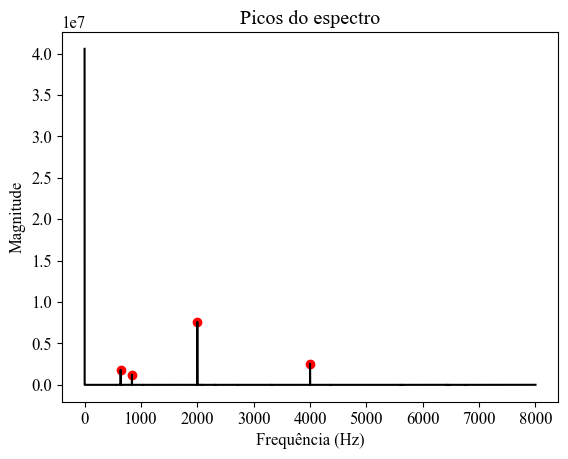

Frequências detectadas:  [ 639.97795426  839.99298544 2000.         4000.        ]


In [75]:
picos, freqs = detectar_frequencias(mag, freq, threshold = 0.005)

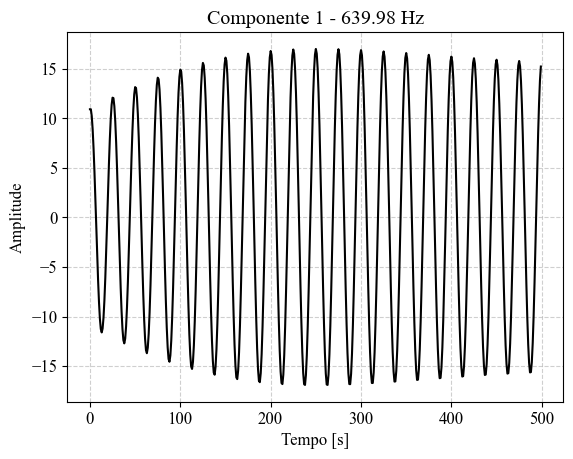

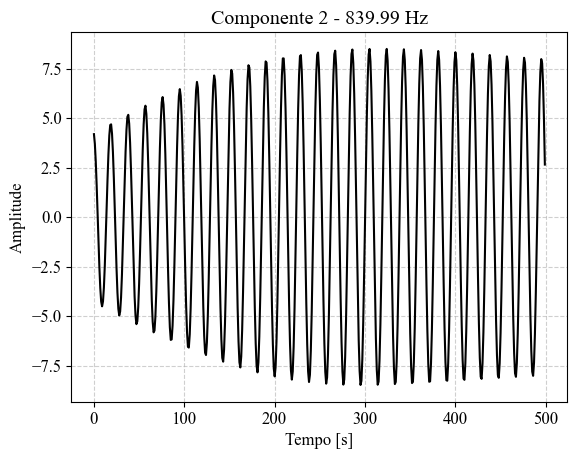

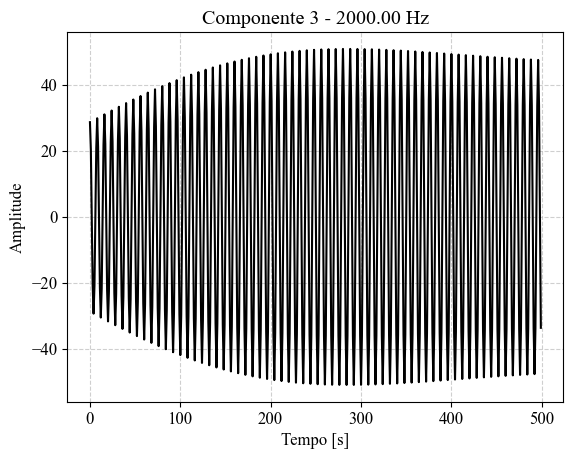

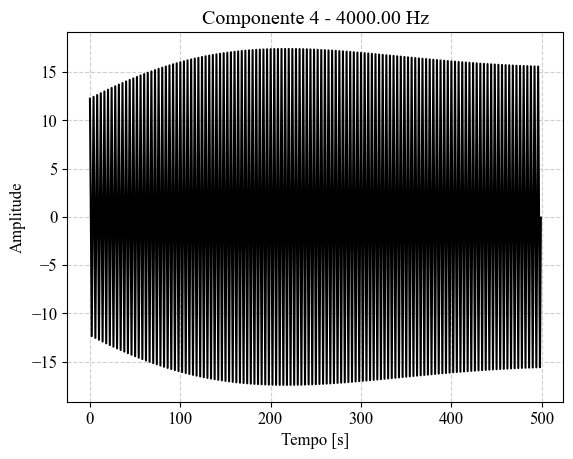

In [76]:
componentes = separar_componentes_iir(wav_array, fs, freqs)

for i, y in enumerate(componentes):

    plt.figure()
    plt.plot(y[:500], color = 'black')
    plt.title(f"Componente {i+1} - {freqs[i]:.2f} Hz")
    plt.grid(True, linestyle = '--', alpha = 0.6)
    plt.xlabel("Tempo [s]")
    plt.ylabel("Amplitude")
    plt.show()